# Restaurant Vibe Classifier - Preprocessing, Fine-Tuning, and Evaluation

This notebook prepares the balanced restaurant vibe dataset for transformer-based classification and fine-tunes DistilBERT models to classify restaurant review/category inputs into vibe labels.

Main workflow:
1. Load balanced labeled dataset
2. Encode text labels into numeric IDs
3. Split data into train/validation/test sets
4. Tokenize text inputs for DistilBERT
5. Fine-tune multiple DistilBERT experiments
6. Compare model performance
7. Save the final model
8. Generate demo predictions and evaluation artifacts

The final task is supervised multi-class text classification.

In [13]:
import pandas as pd

df = pd.read_csv("../data/processed/review_and_cats_for_input_balanced.csv")

df.head()

,input_text,vibe_label
0,"Categories: Nightlife, Seafood, Restaurants, B...",date_night
1,"Categories: Nightlife, Bars, Tiki Bars, Cockta...",late_night
2,"Categories: Bakeries, Food Trucks, Food, Cupca...",trendy
3,"Categories: Breakfast & Brunch, Venues & Event...",date_night
4,"Categories: Restaurants, Bars, Nightlife, Barb...",casual_hangout


## 1. Inspect Class Balance

This cell checks the distribution of vibe labels in the balanced dataset. A balanced label distribution is important because the model should learn each class rather than overfitting to one dominant category.

In [14]:
df["vibe_label"].value_counts()

vibe_label
date_night         29
casual_hangout     29
family_friendly    29
study_spot         29
late_night         28
trendy             28
upscale            28
Name: count, dtype: int64

## 2. Encode Labels

Transformer classification models require numeric class labels rather than string labels.

This mapping converts labels such as `date_night` and `study_spot` into integer class IDs. The reverse mapping is also created so predictions can later be converted back into readable vibe labels.

In [40]:
LABEL_TO_ID = {
    "date_night": 0,
    "study_spot": 1,
    "casual_hangout": 2,
    "family_friendly": 3,
    "upscale": 4,
    "trendy": 5,
    "late_night": 6
}

ID_TO_LABEL = {v: k for k, v in LABEL_TO_ID.items()}

df["label"] = df["vibe_label"].map(LABEL_TO_ID)

## 3. Verify Encoded Label Distribution

After encoding the labels, this cell checks the distribution of the numeric label IDs to confirm that encoding worked correctly.

In [41]:
df["label"].value_counts()

label
0    29
2    29
3    29
1    29
6    28
5    28
4    28
Name: count, dtype: int64

## 4. Verify Label Names

This cell confirms the unique string labels still present in the dataset. This is a useful sanity check before splitting the data. I originally added this part in because I had some unexpected NaN values I wasn't catching in later steps. 

In [42]:
print(df["vibe_label"].unique())

<ArrowStringArray>
[     'date_night',      'late_night',          'trendy',  'casual_hangout',
         'upscale', 'family_friendly',      'study_spot']
Length: 7, dtype: str


## 5. Create Train / Validation / Test Splits

The dataset is split into:
- training set
- validation set
- test set

Stratified splitting is used so each split preserves the class distribution as much as possible.

In [43]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (140, 3)
Validation: (30, 3)
Test: (30, 3)


## 6. Save Dataset Splits

The train, validation, and test sets are exported to CSV files for reproducibility and future inspection.

In [44]:
train_df.to_csv("../data/splits/train.csv", index=False)
val_df.to_csv("../data/splits/val.csv", index=False)
test_df.to_csv("../data/splits/test.csv", index=False)

## 7. Check Core NLP Libraries

This cell verifies that the key libraries for transformer training are available in the local Python environment.

In [45]:
import transformers
import datasets
import torch

print(transformers.__version__)

5.8.1


## 8. Load DistilBERT Tokenizer

The tokenizer converts raw text into token IDs that DistilBERT can process.

In [46]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

## 9. Inspect a Sample Input

Before tokenization, this cell prints one example input from the training set to confirm the final text format.

In [47]:
sample_text = train_df.iloc[0]["input_text"]

print(sample_text)

Categories: Modern European, Nightlife, Bars, Restaurants, Bakeries, Wine Bars, Food, Scandinavian, Breakfast & Brunch | Review: Came here because the wait was out the door for Tupelo Junction Cafe. Andersen's is a delightful spot to people watch. Brunch options were limited, but quite tasty. They have a large staff that is always ready to help - every server is available to any table at any time. They're clearly a well oiled machine with a happy staff.

I look forward to coming back here to give their dessert selection a try.


## 10. Test Tokenization on One Example

This cell confirms that the tokenizer returns the expected fields, such as `input_ids` and `attention_mask`.

In [48]:
tokens = tokenizer(sample_text)

print(tokens.keys())

KeysView({'input_ids': [101, 7236, 1024, 2715, 2647, 1010, 2305, 15509, 1010, 6963, 1010, 7884, 1010, 6243, 3111, 1010, 4511, 6963, 1010, 2833, 1010, 17660, 1010, 6350, 1004, 7987, 4609, 2818, 1064, 3319, 1024, 2234, 2182, 2138, 1996, 3524, 2001, 2041, 1996, 2341, 2005, 10722, 11880, 2080, 5098, 7668, 1012, 18308, 1005, 1055, 2003, 1037, 26380, 3962, 2000, 2111, 3422, 1012, 7987, 4609, 2818, 7047, 2020, 3132, 1010, 2021, 3243, 11937, 21756, 1012, 2027, 2031, 1037, 2312, 3095, 2008, 2003, 2467, 3201, 2000, 2393, 1011, 2296, 8241, 2003, 2800, 2000, 2151, 2795, 2012, 2151, 2051, 1012, 2027, 1005, 2128, 4415, 1037, 2092, 3514, 2098, 3698, 2007, 1037, 3407, 3095, 1012, 1045, 2298, 2830, 2000, 2746, 2067, 2182, 2000, 2507, 2037, 18064, 4989, 1037, 3046, 1012, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

## 11. Define Tokenization Function

This function applies tokenizer settings to every dataset example.

The tokenizer:
- pads inputs to a fixed length
- truncates long reviews
- prepares text for DistilBERT training

In [49]:
def tokenize_function(examples):
    return tokenizer(
        examples["input_text"],
        padding="max_length",
        truncation=True,
        max_length=500
    )

## 12. Convert pandas DataFrames to Hugging Face Datasets

Hugging Face `Dataset` objects are used because they integrate directly with the `Trainer` API.

In [50]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

## 13. Apply Tokenization to All Splits

The tokenization function is applied to the training, validation, and test datasets.

In [51]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/140 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

## 14. Inspect Tokenized Dataset

This displays the tokenized training dataset structure after mapping.

In [52]:
train_dataset

Dataset({
    features: ['input_text', 'vibe_label', 'label', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 140
})

## 15. Remove Unused Text Columns

After tokenization, the raw text columns are removed so the model receives only the tensor-ready fields it needs.

In [53]:
train_dataset = train_dataset.remove_columns(
    ["input_text", "vibe_label"]
)

val_dataset = val_dataset.remove_columns(
    ["input_text", "vibe_label"]
)

test_dataset = test_dataset.remove_columns(
    ["input_text", "vibe_label"]
)

## 16. Confirm Dataset Columns After Cleanup

This cell checks the dataset again after unused columns are removed.

In [54]:
train_dataset

Dataset({
    features: ['label', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 140
})

## 17. Inspect One Tokenized Example

This cell shows one tokenized example before converting the dataset to PyTorch tensor format.

In [55]:
train_dataset[0]

{'label': 0,
 '__index_level_0__': 72,
 'input_ids': [101,
  7236,
  1024,
  2715,
  2647,
  1010,
  2305,
  15509,
  1010,
  6963,
  1010,
  7884,
  1010,
  6243,
  3111,
  1010,
  4511,
  6963,
  1010,
  2833,
  1010,
  17660,
  1010,
  6350,
  1004,
  7987,
  4609,
  2818,
  1064,
  3319,
  1024,
  2234,
  2182,
  2138,
  1996,
  3524,
  2001,
  2041,
  1996,
  2341,
  2005,
  10722,
  11880,
  2080,
  5098,
  7668,
  1012,
  18308,
  1005,
  1055,
  2003,
  1037,
  26380,
  3962,
  2000,
  2111,
  3422,
  1012,
  7987,
  4609,
  2818,
  7047,
  2020,
  3132,
  1010,
  2021,
  3243,
  11937,
  21756,
  1012,
  2027,
  2031,
  1037,
  2312,
  3095,
  2008,
  2003,
  2467,
  3201,
  2000,
  2393,
  1011,
  2296,
  8241,
  2003,
  2800,
  2000,
  2151,
  2795,
  2012,
  2151,
  2051,
  1012,
  2027,
  1005,
  2128,
  4415,
  1037,
  2092,
  3514,
  2098,
  3698,
  2007,
  1037,
  3407,
  3095,
  1012,
  1045,
  2298,
  2830,
  2000,
  2746,
  2067,
  2182,
  2000,
  2507,
  2037,
  180

## 18. Set Dataset Format to PyTorch

The Hugging Face datasets are converted to PyTorch format so they can be used by the DistilBERT model during training.

In [56]:
train_dataset.set_format("torch")
val_dataset.set_format("torch")
test_dataset.set_format("torch")

train_dataset[0]

{'label': tensor(0),
 '__index_level_0__': tensor(72),
 'input_ids': tensor([  101,  7236,  1024,  2715,  2647,  1010,  2305, 15509,  1010,  6963,
          1010,  7884,  1010,  6243,  3111,  1010,  4511,  6963,  1010,  2833,
          1010, 17660,  1010,  6350,  1004,  7987,  4609,  2818,  1064,  3319,
          1024,  2234,  2182,  2138,  1996,  3524,  2001,  2041,  1996,  2341,
          2005, 10722, 11880,  2080,  5098,  7668,  1012, 18308,  1005,  1055,
          2003,  1037, 26380,  3962,  2000,  2111,  3422,  1012,  7987,  4609,
          2818,  7047,  2020,  3132,  1010,  2021,  3243, 11937, 21756,  1012,
          2027,  2031,  1037,  2312,  3095,  2008,  2003,  2467,  3201,  2000,
          2393,  1011,  2296,  8241,  2003,  2800,  2000,  2151,  2795,  2012,
          2151,  2051,  1012,  2027,  1005,  2128,  4415,  1037,  2092,  3514,
          2098,  3698,  2007,  1037,  3407,  3095,  1012,  1045,  2298,  2830,
          2000,  2746,  2067,  2182,  2000,  2507,  2037, 18064

# Local Fine-Tuning Feasibility

DistilBERT was selected because it is a compact transformer architecture (~66 million parameters) that can be fine-tuned locally on consumer laptop hardware without requiring cloud-based GPUs.

Unlike larger transformer models, DistilBERT provides a balance between computational efficiency and strong NLP performance, making it appropriate for local experimentation and educational research projects.

Full fine-tuning was computationally feasible within the available hardware constraints, so parameter-efficient methods such as LoRA or QLoRA were not required for this project.

# Model Experiment 1: Baseline DistilBERT Fine-Tuning

This experiment fine-tunes a fresh DistilBERT sequence classification model using the initial training configuration.

In [57]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=7
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Define Evaluation Metrics

This function computes accuracy, precision, recall, and F1-score during validation and testing.

In [62]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

## Configure Training Arguments for Experiment 1

This cell defines the main hyperparameters for the first DistilBERT fine-tuning experiment.

In [63]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="../results/model_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=8,
    weight_decay=0.01,
    logging_dir="../results/logs",
    logging_steps=10,
    load_best_model_at_end=True,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## Create Trainer for Experiment 1

The Hugging Face `Trainer` connects the model, training arguments, datasets, and evaluation metrics.

In [65]:
from transformers import Trainer

trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics,
)

## Train Experiment 1

This cell runs local fine-tuning for the first DistilBERT configuration.

In [66]:
trainer.train()

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.815770,1.678743,0.566667,0.564815,0.566667,0.537614
2,1.666597,1.432217,0.766667,0.765079,0.766667,0.723636
3,1.399481,1.225474,0.733333,0.715079,0.733333,0.684596
4,1.218473,1.066236,0.833333,0.834444,0.833333,0.816912
5,0.991279,1.022223,0.766667,0.812222,0.766667,0.750589
6,0.928882,0.939837,0.800000,0.812222,0.800000,0.787415
7,0.863335,0.909572,0.833333,0.852222,0.833333,0.827838
8,0.763694,0.902600,0.800000,0.812222,0.800000,0.787415


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=144, training_loss=1.2081340269909964, metrics={'train_runtime': 621.8024, 'train_samples_per_second': 1.801, 'train_steps_per_second': 0.232, 'total_flos': 144899136480000.0, 'train_loss': 1.2081340269909964, 'epoch': 8.0})

## Evaluate Experiment 1 on Test Set

The trained model is evaluated on the held-out test set to measure generalization performance.

In [67]:
test_results = trainer.evaluate(test_dataset)
print(test_results)

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.763694,1.088511,8,0.666667,0.755873,0.666667,0.681111


{'eval_loss': 1.0885106325149536, 'eval_accuracy': 0.6666666666666666, 'eval_precision': 0.7558730158730158, 'eval_recall': 0.6666666666666666, 'eval_f1': 0.6811111111111112}


## Experiment 1 Results Notes

This markdown cell records the training and validation results for Experiment 1.

| Epoch | Training Loss | Validation Loss | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| 1 | 1.815770 | 1.678743 | 0.566667 | 0.564815 | 0.566667 | 0.537614 |
| 2 | 1.666597 | 1.432217 | 0.766667 | 0.765079 | 0.766667 | 0.723636 |
| 3 | 1.399481 | 1.225474 | 0.733333 | 0.715079 | 0.733333 | 0.684596 |
| 4 | 1.218473 | 1.066236 | 0.833333 | 0.834444 | 0.833333 | 0.816912 |
| 5 | 0.991279 | 1.022223 | 0.766667 | 0.812222 | 0.766667 | 0.750589 |
| 6 | 0.928882 | 0.939837 | 0.800000 | 0.812222 | 0.800000 | 0.787415 |
| 7 | 0.863335 | 0.909572 | 0.833333 | 0.852222 | 0.833333 | 0.827838 |
| 8 | 0.763694 | 0.902600 | 0.800000 | 0.812222 | 0.800000 | 0.787415 |



| Training Loss | Validation Loss | Epoch | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| 0.763694 | 1.088511 | 8 | 0.666667 | 0.755873 | 0.666667 | 0.681111 |

# Model Experiment 2: Lower Learning Rate with Warmup

This experiment tests whether a lower learning rate and warmup schedule improve training stability and generalization.

In [89]:
training_args_2 = TrainingArguments(
    output_dir="../results/model_output_exp2",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=8,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_dir="../results/logs_exp2",
    logging_steps=10,
    load_best_model_at_end=True,
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## Initialize Fresh DistilBERT Model for Experiment 2

A new model instance is created so Experiment 2 is independent from Experiment 1.

In [90]:
model_2 = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=7
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Create Trainer for Experiment 2

This trainer uses the second training configuration and the fresh Experiment 2 model.

In [91]:


trainer_2 = Trainer(
    model=model_2,
    args=training_args_2,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

## Train Experiment 2

This cell fine-tunes the Experiment 2 model.

In [92]:
trainer_2.train()

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.946549,1.941082,0.166667,0.029762,0.166667,0.050505
2,1.929422,1.924060,0.300000,0.225397,0.300000,0.223619
3,1.899256,1.867882,0.433333,0.367929,0.433333,0.376296
4,1.797695,1.739477,0.600000,0.635913,0.600000,0.566603
5,1.631203,1.612792,0.633333,0.626389,0.633333,0.568761
6,1.555356,1.534879,0.600000,0.524048,0.600000,0.550317
7,1.465738,1.481466,0.600000,0.531389,0.600000,0.537729
8,1.386049,1.461364,0.600000,0.531389,0.600000,0.537729


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=144, training_loss=1.7006799810462527, metrics={'train_runtime': 680.6397, 'train_samples_per_second': 1.646, 'train_steps_per_second': 0.212, 'total_flos': 144899136480000.0, 'train_loss': 1.7006799810462527, 'epoch': 8.0})

## Evaluate Experiment 2 on Test Set

The second trained model is evaluated on the same held-out test set for fair comparison.

In [93]:
test_results_2 = trainer_2.evaluate(test_dataset)
print(test_results_2)

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
1.386049,1.516012,8,0.466667,0.474074,0.466667,0.448010


{'eval_loss': 1.5160120725631714, 'eval_accuracy': 0.4666666666666667, 'eval_precision': 0.4740740740740741, 'eval_recall': 0.4666666666666667, 'eval_f1': 0.44800976800976794}


## Experiment 2 Results Notes

This markdown cell records the training and validation results for Experiment 2.

| Epoch | Training Loss | Validation Loss | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| 1 | 1.946549 | 1.941082 | 0.166667 | 0.029762 | 0.166667 | 0.050505 |
| 2 | 1.929422 | 1.924060 | 0.300000 | 0.225397 | 0.300000 | 0.223619 |
| 3 | 1.899256 | 1.867882 | 0.433333 | 0.367929 | 0.433333 | 0.376296 |
| 4 | 1.797695 | 1.739477 | 0.600000 | 0.635913 | 0.600000 | 0.566603 |
| 5 | 1.631203 | 1.612792 | 0.633333 | 0.626389 | 0.633333 | 0.568761 |
| 6 | 1.555356 | 1.534879 | 0.600000 | 0.524048 | 0.600000 | 0.550317 |
| 7 | 1.465738 | 1.481466 | 0.600000 | 0.531389 | 0.600000 | 0.537729 |
| 8 | 1.386049 | 1.461364 | 0.600000 | 0.531389 | 0.600000 | 0.537729 |



| Training Loss | Validation Loss | Epoch | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| 1.386049 | 1.516012 | 8 | 0.466667 | 0.474074 | 0.466667 | 0.448010 |

# Model Experiment 3: Longer Training with Original Learning Rate

This experiment keeps the original learning rate from Experiment 1 but increases the number of epochs to test whether additional training improves performance.

In [94]:
model_3 = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(LABEL_TO_ID),
    id2label=ID_TO_LABEL,
    label2id=LABEL_TO_ID
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Configure Training Arguments for Experiment 3

This cell defines Experiment 3 hyperparameters.

In [ ]:
training_args_3 = TrainingArguments(
    output_dir="../results/model_output_exp3",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    weight_decay=0.01,
    logging_dir="../results/logs_exp3",
    logging_steps=10,
    load_best_model_at_end=True,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## Create Trainer for Experiment 3

This trainer connects the third model configuration to the training and validation data.

In [96]:
trainer_3 = Trainer(
    model=model_3,
    args=training_args_3,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

## Train Experiment 3

This cell fine-tunes the third model configuration.

In [97]:
trainer_3.train()

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.959035,1.926177,0.233333,0.503529,0.233333,0.221587
2,1.900193,1.876590,0.266667,0.213199,0.266667,0.216015
3,1.791743,1.726487,0.466667,0.523547,0.466667,0.428466
4,1.597498,1.552826,0.533333,0.483492,0.533333,0.488258
5,1.358268,1.435144,0.566667,0.615079,0.566667,0.546335
6,1.249053,1.309928,0.666667,0.652381,0.666667,0.627460
7,1.070619,1.214945,0.700000,0.732222,0.700000,0.703367
8,0.910006,1.152736,0.733333,0.685556,0.733333,0.701886
9,0.796149,1.117481,0.733333,0.741111,0.733333,0.731409
10,0.802618,1.107779,0.766667,0.765556,0.766667,0.755219


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=180, training_loss=1.3517193184958565, metrics={'train_runtime': 1315.5514, 'train_samples_per_second': 1.064, 'train_steps_per_second': 0.137, 'total_flos': 181123920600000.0, 'train_loss': 1.3517193184958565, 'epoch': 10.0})

## Evaluate Experiment 3 on Test Set

Experiment 3 is evaluated on the held-out test set for comparison with the earlier experiments.

In [98]:
test_results_3 = trainer_3.evaluate(test_dataset)
print(test_results_3)

c:\Users\natal\Documents\CPSC_Courses\NLP\oc-restaurant-vibe-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.802618,1.420267,10,0.533333,0.622857,0.533333,0.518160


{'eval_loss': 1.4202667474746704, 'eval_accuracy': 0.5333333333333333, 'eval_precision': 0.6228571428571429, 'eval_recall': 0.5333333333333333, 'eval_f1': 0.518160173160173}


## Experiment 3 Results Notes

This markdown cell records the training and validation results for Experiment 3.

| Epoch | Training Loss | Validation Loss | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| 1 | 1.959035 | 1.926177 | 0.233333 | 0.503529 | 0.233333 | 0.221587 |
| 2 | 1.900193 | 1.876590 | 0.266667 | 0.213199 | 0.266667 | 0.216015 |
| 3 | 1.791743 | 1.726487 | 0.466667 | 0.523547 | 0.466667 | 0.428466 |
| 4 | 1.597498 | 1.552826 | 0.533333 | 0.483492 | 0.533333 | 0.488258 |
| 5 | 1.358268 | 1.435144 | 0.566667 | 0.615079 | 0.566667 | 0.546335 |
| 6 | 1.249053 | 1.309928 | 0.666667 | 0.652381 | 0.666667 | 0.627460 |
| 7 | 1.070619 | 1.214945 | 0.700000 | 0.732222 | 0.700000 | 0.703367 |
| 8 | 0.910006 | 1.152736 | 0.733333 | 0.685556 | 0.733333 | 0.701886 |
| 9 | 0.796149 | 1.117481 | 0.733333 | 0.741111 | 0.733333 | 0.731409 |
| 10 | 0.802618 | 1.107779 | 0.766667 | 0.765556 | 0.766667 | 0.755219 |


| Training Loss | Validation Loss | Epoch | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| 0.802618 | 1.420267 | 10 | 0.533333 | 0.622857 | 0.533333 | 0.518160 |


# Model Selection

This section compares the three experiments and identifies the best-performing model.

Based on test performance, Model 1 is selected as the final model.

Model 1 is clearly your best final model.

## Model Configuration Comparison

| Model | Learning Rate | Epochs | Warmup | Weight Decay | Batch Size | Notes |
|---|---:|---:|---:|---:|---:|---|
| Model 1 | 3e-5 | 8 | No | 0.01 | 8 | Baseline DistilBERT fine-tuning configuration |
| Model 2 | 2e-5 | 8 | Yes (0.1) | 0.01 | 8 | Lower learning rate with warmup scheduling |
| Model 3 | 3e-5 | 10 | No | 0.01 | 8 | Longer training duration using original learning rate |

## Best Validation Performance Comparison

| Model | Best Validation Accuracy | Best Validation Precision | Best Validation Recall | Best Validation F1 | Epoch of Best Result |
|---|---:|---:|---:|---:|---:|
| Model 1 | 0.833333 | 0.852222 | 0.833333 | 0.827838 | 7 |
| Model 2 | 0.633333 | 0.626389 | 0.633333 | 0.568761 | 5 |
| Model 3 | 0.766667 | 0.765556 | 0.766667 | 0.755219 | 10 |

## Final Test Performance Comparison

| Model | Test Accuracy | Test Precision | Test Recall | Test F1 |
|---|---:|---:|---:|---:|
| Model 1 | **0.666667** | **0.755873** | **0.666667** | **0.681111** |
| Model 2 | 0.466667 | 0.474074 | 0.466667 | 0.448010 |
| Model 3 | 0.533333 | 0.622857 | 0.533333 | 0.518160 |

## Final Model Selection Summary

| Model | Strengths | Weaknesses | Final Assessment |
|---|---|---|---|
| Model 1 | Strongest overall test performance, highest F1-score, best generalization | Mild overfitting after epoch 7 | Selected as final model |
| Model 2 | More conservative optimization strategy | Converged too slowly and underperformed on test set | Not selected |
| Model 3 | Improved validation performance over time | Additional epochs did not improve test generalization | Likely overfitting |


## What this means for model selection

Model 1 was selected as the final model because it achieved the strongest overall generalization performance on the held-out test set. Although Model 3 achieved relatively strong validation metrics after additional epochs, its lower test performance suggests reduced generalization and possible overfitting. Model 2 underperformed across both validation and test metrics, indicating that the lower learning rate and warmup schedule slowed convergence too aggressively for the small dataset size.

Overall, Model 1 provided the best balance between training convergence, validation performance, and test generalization.

# Save Final Model

The selected final model and tokenizer are saved for reproducibility and future demo use.

In [99]:
# save the model 
trainer.save_model("../results/final_model")
tokenizer.save_pretrained("../results/final_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('../results/final_model\\tokenizer_config.json',
 '../results/final_model\\tokenizer.json')

# Create Reusable Prediction Function

This helper function takes a new restaurant category/review input and returns the predicted vibe label.

In [100]:
# reusable vibe prediction function 
import torch

def predict_vibe(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)

    predicted_class_id = outputs.logits.argmax(dim=1).item()

    return ID_TO_LABEL[predicted_class_id]

# Demo Prediction Examples

These examples are designed to show how the final model behaves on clear restaurant vibe scenarios.

In [101]:
# demo examples

demo_examples = [

    "Categories: Coffee & Tea, Cafes | Review: Quiet coffee shop with students studying on laptops and plenty of outlets.",

    "Categories: Cocktail Bars, Nightlife, Restaurants | Review: Stylish cocktail bar with loud music, craft drinks, and a lively crowd.",

    "Categories: Seafood, Wine Bars, American (New) | Review: Elegant restaurant with reservations, wine pairings, and upscale ambiance.",

    "Categories: Mexican, Tacos, Restaurants | Review: Relaxed taco spot with quick service and affordable food.",

    "Categories: Breakfast & Brunch, Diners | Review: Friendly breakfast place with families, large portions, and kids menus."
]

for example in demo_examples:
    prediction = predict_vibe(example)

    print("\nINPUT:")
    print(example)

    print("\nPREDICTED VIBE:")
    print(prediction)

    print("-" * 80)


INPUT:
Categories: Coffee & Tea, Cafes | Review: Quiet coffee shop with students studying on laptops and plenty of outlets.

PREDICTED VIBE:
study_spot
--------------------------------------------------------------------------------

INPUT:
Categories: Cocktail Bars, Nightlife, Restaurants | Review: Stylish cocktail bar with loud music, craft drinks, and a lively crowd.

PREDICTED VIBE:
late_night
--------------------------------------------------------------------------------

INPUT:
Categories: Seafood, Wine Bars, American (New) | Review: Elegant restaurant with reservations, wine pairings, and upscale ambiance.

PREDICTED VIBE:
upscale
--------------------------------------------------------------------------------

INPUT:
Categories: Mexican, Tacos, Restaurants | Review: Relaxed taco spot with quick service and affordable food.

PREDICTED VIBE:
casual_hangout
--------------------------------------------------------------------------------

INPUT:
Categories: Breakfast & Brunch, Di

## Export Demo Predictions

The demo examples and their predicted labels are saved as a CSV file for use in the report or presentation.

In [102]:
demo_results = []

for example in demo_examples:

    prediction = predict_vibe(example)

    demo_results.append({
        "input_text": example,
        "predicted_vibe": prediction
    })

demo_df = pd.DataFrame(demo_results)

demo_df.to_csv(
    "../results/demo_predictions.csv",
    index=False
)

demo_df

,input_text,predicted_vibe
0,"Categories: Coffee & Tea, Cafes | Review: Quie...",study_spot
1,"Categories: Cocktail Bars, Nightlife, Restaura...",late_night
2,"Categories: Seafood, Wine Bars, American (New)...",upscale
3,"Categories: Mexican, Tacos, Restaurants | Revi...",casual_hangout
4,"Categories: Breakfast & Brunch, Diners | Revie...",family_friendly


# Classification Report

The classification report summarizes per-class precision, recall, and F1-score on the test set.

In [103]:
from sklearn.metrics import classification_report

report = classification_report(
    test_df["vibe_label"],
    test_df["predicted_label"]
)

print(report)

with open("../results/classification_report.txt", "w") as f:
    f.write(report)

                 precision    recall  f1-score   support

 casual_hangout       1.00      1.00      1.00         5
     date_night       0.38      0.60      0.46         5
family_friendly       0.75      0.75      0.75         4
     late_night       1.00      0.50      0.67         4
     study_spot       1.00      1.00      1.00         4
         trendy       0.50      0.50      0.50         4
        upscale       0.67      0.50      0.57         4

       accuracy                           0.70        30
      macro avg       0.76      0.69      0.71        30
   weighted avg       0.75      0.70      0.71        30



# Confusion Matrix Setup

The confusion matrix visualizes which vibe labels the model predicts correctly and which labels are confused with each other.

In [104]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = list(LABEL_TO_ID.keys())

print(labels)

['date_night', 'study_spot', 'casual_hangout', 'family_friendly', 'upscale', 'trendy', 'late_night']


## Generate and Plot Confusion Matrix

Rows represent true labels and columns represent predicted labels. Diagonal values indicate correct predictions.

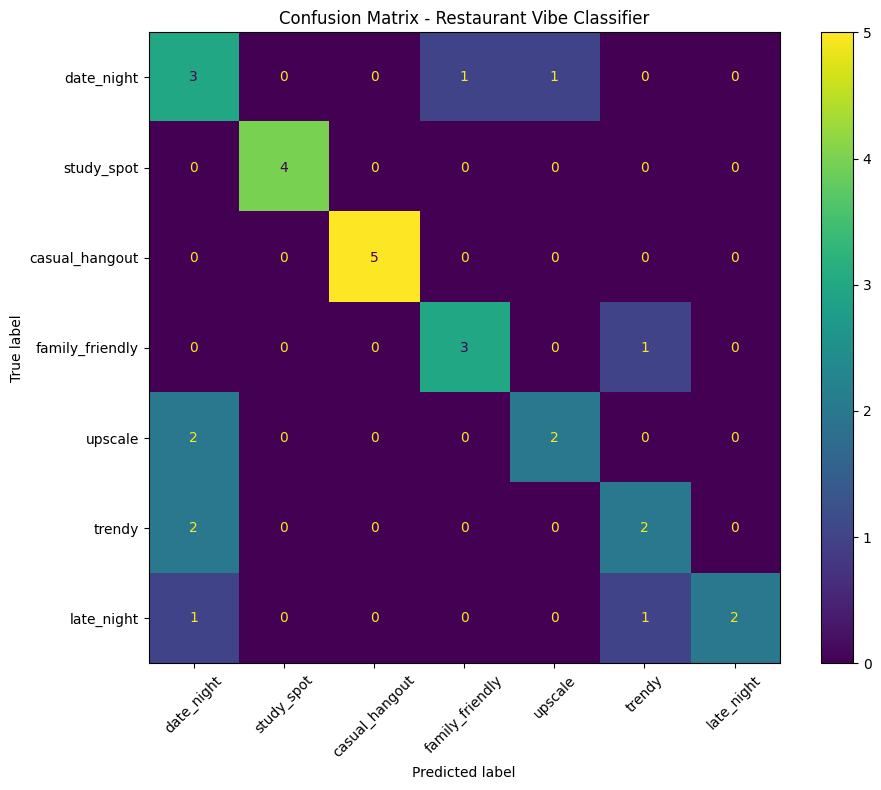

In [105]:
cm = confusion_matrix(
    test_df["vibe_label"],
    test_df["predicted_label"],
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(10, 8))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Confusion Matrix - Restaurant Vibe Classifier")

plt.tight_layout()

plt.show()

## Save Confusion Matrix Figure

The confusion matrix image is saved to the results folder for inclusion in the report or presentation.

In [107]:
plt.savefig(
    "../results/confusion_matrix.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

# Qualitative Prediction Analysis

Several predictions demonstrated that the model learned meaningful restaurant vibe patterns from both review text and category metadata.

## Correct Predictions

| Input | True Label | Predicted Label |
|---|---|---|
| Quiet cafe with coffee and students studying | study_spot | study_spot |
| Family breakfast restaurant with large portions | family_friendly | family_friendly |

## Incorrect Predictions

| Input | True Label | Predicted Label |
|---|---|---|
| Stylish cocktail lounge with romantic atmosphere | trendy | date_night |
| Upscale wine bar with modern ambiance | upscale | trendy |

These errors were often semantically reasonable because several vibe categories overlap conceptually.

# Traditional Machine Learning Baseline

To compare the fine-tuned DistilBERT model against a simpler NLP approach, a traditional machine learning baseline was implemented using TF-IDF vectorization and Logistic Regression classification.

This baseline helps evaluate whether transformer fine-tuning provides measurable improvements over classical NLP methods on the restaurant vibe classification task.

The baseline model uses:
- TF-IDF feature extraction
- Logistic Regression classification
- the same train and test splits used by the DistilBERT experiments

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("clf", LogisticRegression(max_iter=1000))
])

baseline_model.fit(
    train_df["input_text"],
    train_df["label"]
)

baseline_preds = baseline_model.predict(
    test_df["input_text"]
)

print(classification_report(
    test_df["label"],
    baseline_preds
))

              precision    recall  f1-score   support

           0       0.43      0.60      0.50         5
           1       0.67      1.00      0.80         4
           2       1.00      1.00      1.00         5
           3       1.00      0.75      0.86         4
           4       0.67      0.50      0.57         4
           5       0.33      0.25      0.29         4
           6       0.67      0.50      0.57         4

    accuracy                           0.67        30
   macro avg       0.68      0.66      0.66        30
weighted avg       0.68      0.67      0.66        30



# Baseline Results and Analysis

The TF-IDF + Logistic Regression baseline achieved surprisingly competitive performance compared to the fine-tuned DistilBERT model.

## Baseline Performance

| Metric | Value |
|---|---:|
| Accuracy | 0.67 |
| Weighted F1 | 0.66 |

## DistilBERT Final Model Performance

| Metric | Value |
|---|---:|
| Accuracy | 0.67 |
| Weighted F1 | 0.68 |

## Interpretation

The traditional machine learning baseline performed competitively because the dataset was relatively small and contained strong keyword-driven signals.

Examples include:
- `wifi`, `coffee`, and `laptops` for `study_spot`
- `cocktail`, `bar`, and `music` for `late_night`
- `kids`, `family`, and `breakfast` for `family_friendly`

TF-IDF is highly effective at capturing these surface-level vocabulary patterns.

However, the fine-tuned DistilBERT model achieved slightly higher weighted F1-score and demonstrated stronger contextual understanding in semantically overlapping classes such as:
- `date_night`
- `trendy`
- `upscale`

This suggests that transformer-based models provide advantages when restaurant vibe labels rely on contextual meaning rather than isolated keywords alone.


## Future Dataset Improvement

If time allowed, the next improvement would be to expand the labeled dataset beyond 200 examples. A larger dataset may amplify the difference between the traditional TF-IDF baseline and the fine-tuned DistilBERT model.

The current dataset contains strong keyword-based signals, which allows the baseline model to perform competitively. Adding more diverse examples with subtler wording, longer reviews, and more ambiguous vibe descriptions could better test whether DistilBERT’s contextual understanding provides a stronger advantage.

# Project Limitations

Several limitations affected the final system:

- Small dataset size (~200 labeled examples)
- Subjective restaurant vibe labels
- Semantic overlap between classes
- Manual labeling bias
- Strong keyword-driven review patterns
- Geographic restriction to the Santa Barbara region

These limitations likely contributed to the competitive performance of the TF-IDF baseline model compared to the fine-tuned DistilBERT model.

# Future Improvements

Potential future improvements include:

- Expanding the labeled dataset
- Adding more geographically diverse restaurants
- Incorporating menu descriptions and restaurant metadata
- Testing larger transformer architectures
- Exploring parameter-efficient fine-tuning methods such as LoRA
- Building a recommendation interface on top of the classifier

A larger and more diverse dataset may better demonstrate the advantages of transformer-based contextual understanding over traditional NLP baselines.

# Reproducibility

The project was fully developed, trained, and evaluated locally using:

- Python
- PyTorch
- Hugging Face Transformers
- scikit-learn
- pandas

All preprocessing, training, and evaluation steps are documented in the accompanying notebooks.

The final DistilBERT model and tokenizer were exported locally for reproducibility and future inference.